# SDC-2022 Multipath — Exploratory Data Analysis & Feature Engineering

Explores the 2022 GNSS measurement dataset and engineers the feature matrix for the classifier. The label is each device's own `MultipathIndicator`.

**Input:** `data/02_interim/sdc2022_epochs.csv`

**Output:** `data/03_processed/sdc2022_training_features.csv`

## 1. Library Import & Data Loading

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

BASE_DIR   = os.path.abspath(os.path.join(os.getcwd(), '../..'))
INPUT_CSV  = os.path.join(BASE_DIR, 'data/02_interim/sdc2022_epochs.csv')
OUTPUT_DIR = os.path.join(BASE_DIR, 'data/03_processed')
OUTPUT_CSV = os.path.join(OUTPUT_DIR, 'sdc2022_training_features.csv')
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(INPUT_CSV)
pd.set_option('display.max_columns', None)
print(f'Loaded {len(df):,} rows from {INPUT_CSV}')
df.head()

Loaded 620,636 rows from C:\Users\Dell\Documents\Warwick\Diss\Code\Dissertation_Trial\GNSS_Multipath_Project\data/02_interim/sdc2022_epochs.csv


,State,Svid,ReceivedSvTimeUncertaintyNanos,Cn0DbHz,BasebandCn0DbHz,SnrInDb,AgcDb,PseudorangeRateMetersPerSecond,PseudorangeRateUncertaintyMetersPerSecond,AccumulatedDeltaRangeState,AccumulatedDeltaRangeMeters,AccumulatedDeltaRangeUncertaintyMeters,CarrierFrequencyHz,ConstellationType,MultipathIndicator,SvElevationDegrees,SvAzimuthDegrees,RawPseudorangeMeters,RawPseudorangeUncertaintyMeters,session,device,GpsTimeNanos,prResidual
0,47,3,17,35.867416,NaN,NaN,NaN,594.420187,0.002924,17,101863.658418,0.001462,1575420000,1,0,42.065444,175.396281,2.193652e+07,5.096472,2022-01-11-18-48-us-ca-mtv-n,mi8,240540000366384,-31.072611
1,47,4,12,42.319908,NaN,NaN,NaN,48.766446,0.001466,17,7419.984661,0.000733,1575420000,1,0,69.824656,46.728665,2.053317e+07,3.597509,2022-01-11-18-48-us-ca-mtv-n,mi8,240540000366384,-20.017892
2,47,6,21,33.128010,NaN,NaN,NaN,302.023892,0.004009,17,51046.019632,0.002004,1575420000,1,0,13.110256,277.077207,2.439315e+07,6.295642,2022-01-11-18-48-us-ca-mtv-n,mi8,240540000366384,161.380937
3,47,7,15,37.043587,NaN,NaN,NaN,-368.476984,0.002554,17,-64584.061018,0.001277,1575420000,1,0,36.256790,255.396843,2.257167e+07,4.496887,2022-01-11-18-48-us-ca-mtv-n,mi8,240540000366384,2.367246
4,47,9,14,37.668007,NaN,NaN,NaN,-328.389457,0.002377,17,-57639.261147,0.001188,1575420000,1,0,54.089851,318.827182,2.119126e+07,4.197094,2022-01-11-18-48-us-ca-mtv-n,mi8,240540000366384,-2.308638


## 2. Dataset Overview

In [2]:
print('--- Info ---')
df.info()
print('\n--- Statistical Summary ---')
df.describe()

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 620636 entries, 0 to 620635
Data columns (total 23 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   State                                      620636 non-null  int64  
 1   Svid                                       620636 non-null  int64  
 2   ReceivedSvTimeUncertaintyNanos             620636 non-null  int64  
 3   Cn0DbHz                                    620636 non-null  float64
 4   BasebandCn0DbHz                            0 non-null       float64
 5   SnrInDb                                    0 non-null       float64
 6   AgcDb                                      0 non-null       float64
 7   PseudorangeRateMetersPerSecond             620636 non-null  float64
 8   PseudorangeRateUncertaintyMetersPerSecond  620636 non-null  float64
 9   AccumulatedDeltaRangeState                 620636 non-null  int64  


,State,Svid,ReceivedSvTimeUncertaintyNanos,Cn0DbHz,BasebandCn0DbHz,SnrInDb,AgcDb,PseudorangeRateMetersPerSecond,PseudorangeRateUncertaintyMetersPerSecond,AccumulatedDeltaRangeState,AccumulatedDeltaRangeMeters,AccumulatedDeltaRangeUncertaintyMeters,CarrierFrequencyHz,ConstellationType,MultipathIndicator,SvElevationDegrees,SvAzimuthDegrees,RawPseudorangeMeters,RawPseudorangeUncertaintyMeters,GpsTimeNanos,prResidual
count,620636.000000,620636.000000,620636.000000,620636.000000,0.0,0.0,0.0,620636.000000,620636.000000,620636.000000,6.206360e+05,6.206360e+05,6.206360e+05,620636.000000,620636.000000,592004.000000,592004.000000,5.920040e+05,592004.000000,6.206360e+05,5.920040e+05
mean,56331.988020,20.913680,27.024001,33.067603,NaN,NaN,NaN,82.464260,8.698748,19.783659,4.918679e+04,1.267311e+38,1.455599e+09,3.535372,0.064166,40.353891,188.730870,2.503988e+07,7.433464,4.044196e+14,-7.084901e+00
std,34544.220042,24.378858,23.839847,6.602770,NaN,NaN,NaN,377.345243,49.051686,3.916584,4.373981e+05,1.645103e+38,1.809549e+08,2.345258,0.245049,20.968198,104.984885,5.315152e+06,5.826174,1.078377e+14,6.388326e+03
min,13.000000,1.000000,6.000000,9.020374,NaN,NaN,NaN,-857.032476,0.000678,16.000000,-1.690258e+06,3.387955e-04,1.176450e+09,1.000000,0.000000,0.899135,0.002944,1.011573e+07,1.798755,1.760480e+14,-4.071184e+06
25%,16431.000000,8.000000,12.000000,28.366898,NaN,NaN,NaN,-219.559960,0.011124,16.000000,-1.558153e+05,1.856461e-03,1.176450e+09,1.000000,0.000000,22.051753,75.409463,2.211310e+07,3.597509,3.322250e+14,-1.499342e+01
50%,81921.000000,19.000000,19.000000,33.263592,NaN,NaN,NaN,79.163790,0.150000,17.000000,1.417420e+04,4.750649e-03,1.575420e+09,5.000000,0.000000,39.449494,198.573536,2.394192e+07,5.696057,4.144310e+14,0.000000e+00
75%,84011.000000,27.000000,33.000000,37.939508,NaN,NaN,NaN,417.486342,0.810447,25.000000,2.559270e+05,3.402823e+38,1.575420e+09,6.000000,0.000000,58.051328,287.969842,2.549732e+07,9.293566,5.077400e+14,1.415358e+01
max,85034.000000,194.000000,496.000000,51.556999,NaN,NaN,NaN,1005.731643,299.804318,29.000000,2.273184e+06,3.402823e+38,1.605375e+09,6.000000,1.000000,81.441723,359.997369,5.683963e+07,118.118228,5.096220e+14,1.329911e+06


## 3. Target Variable Distribution

Overall class balance and the per-session breakdown.

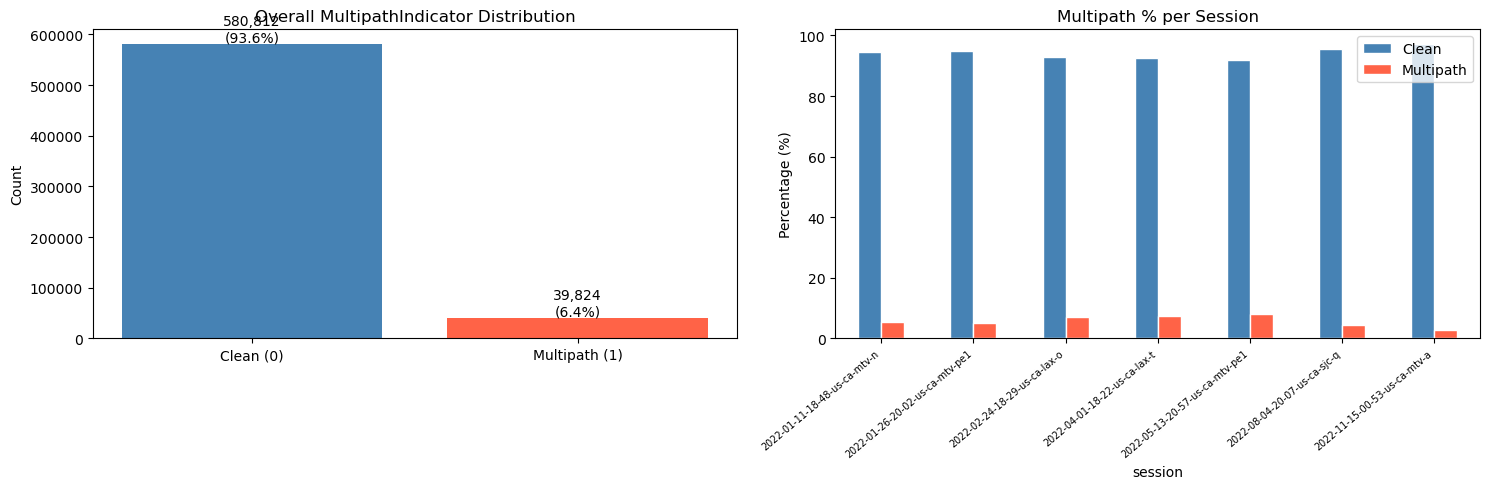

Class imbalance: 6.4% multipath


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

counts = df['MultipathIndicator'].value_counts().sort_index()
axes[0].bar(['Clean (0)', 'Multipath (1)'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Overall MultipathIndicator Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f'{v:,}\n({100*v/len(df):.1f}%)', ha='center', va='bottom')

sess_pct = (df.groupby(['session', 'MultipathIndicator']).size()
            .unstack(fill_value=0).apply(lambda r: 100 * r / r.sum(), axis=1))
sess_pct.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('Multipath % per Session')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=40, ha='right', fontsize=7)
axes[1].legend(['Clean', 'Multipath'])
plt.tight_layout()
plt.show()
print(f'Class imbalance: {100*counts.get(1,0)/len(df):.1f}% multipath')

## 4. Feature Distributions by Class

Boxplots comparing the key measurement + geometry features between clean and multipath epochs. The physical expectation: multipath measurements have **lower C/N0, lower elevation, and larger pseudorange residuals**.

C:\Users\Dell\AppData\Local\Temp\ipykernel_2740\1938765036.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['Clean', 'Multipath'], patch_artist=True,
C:\Users\Dell\AppData\Local\Temp\ipykernel_2740\1938765036.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['Clean', 'Multipath'], patch_artist=True,
C:\Users\Dell\AppData\Local\Temp\ipykernel_2740\1938765036.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['Clean', 'Multipath'], patch_artist=True,
C:\Users\Dell\AppData\Local\Temp\ipykernel_2740\1938765036.py:19: MatplotlibDeprec

C:\Users\Dell\AppData\Local\Temp\ipykernel_2740\1938765036.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['Clean', 'Multipath'], patch_artist=True,


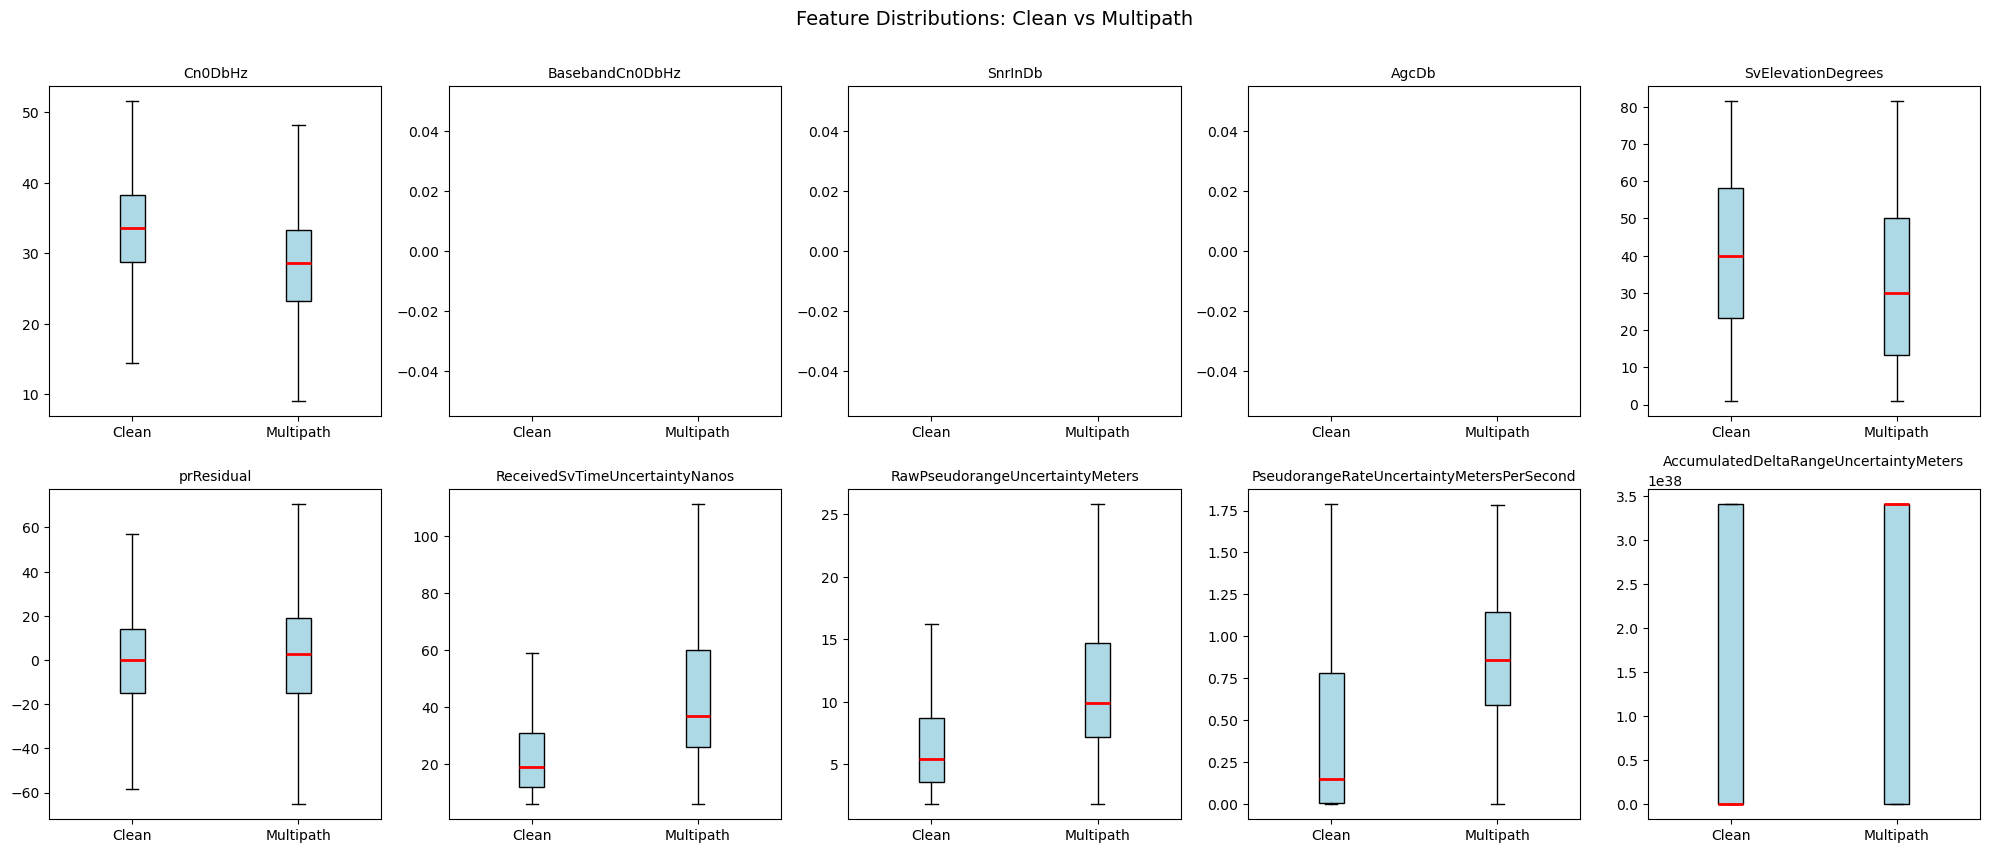

In [4]:
PLOT_FEATURES = [
    'Cn0DbHz', 'BasebandCn0DbHz', 'SnrInDb', 'AgcDb',
    'SvElevationDegrees', 'prResidual',
    'ReceivedSvTimeUncertaintyNanos', 'RawPseudorangeUncertaintyMeters',
    'PseudorangeRateUncertaintyMetersPerSecond',
    'AccumulatedDeltaRangeUncertaintyMeters',
]
available_plot = [f for f in PLOT_FEATURES if f in df.columns]

ncols = 5
nrows = int(np.ceil(len(available_plot) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4.2 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, feat in enumerate(available_plot):
    ax = axes[i]
    data_plot = df[[feat, 'MultipathIndicator']].dropna()
    groups = [data_plot.loc[data_plot['MultipathIndicator'] == v, feat] for v in [0, 1]]
    ax.boxplot(groups, labels=['Clean', 'Multipath'], patch_artist=True,
               boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='red', linewidth=2), showfliers=False)
    ax.set_title(feat, fontsize=10)

for j in range(len(available_plot), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature Distributions: Clean vs Multipath', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Elevation & C/N0 — The Multipath Signature

Multipath is strongest for **low-elevation** satellites (signals grazing buildings/terrain) and shows up as **depressed C/N0**. This 2-D view makes the separation explicit.

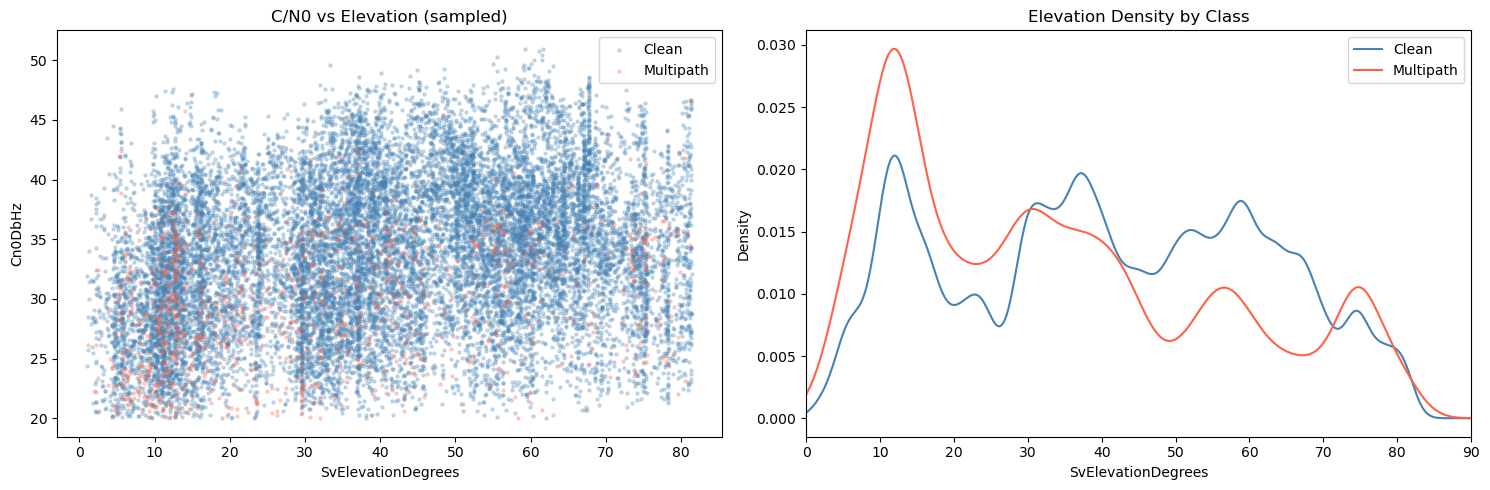

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sample = df.sample(min(20000, len(df)), random_state=42)
for val, label, color in [(0, 'Clean', 'steelblue'), (1, 'Multipath', 'tomato')]:
    sub = sample[sample['MultipathIndicator'] == val]
    axes[0].scatter(sub['SvElevationDegrees'], sub['Cn0DbHz'], s=5, alpha=0.25,
                    color=color, label=label)
axes[0].set_xlabel('SvElevationDegrees')
axes[0].set_ylabel('Cn0DbHz')
axes[0].set_title('C/N0 vs Elevation (sampled)')
axes[0].legend()

for val, label, color in [(0, 'Clean', 'steelblue'), (1, 'Multipath', 'tomato')]:
    subset = df.loc[df['MultipathIndicator'] == val, 'SvElevationDegrees'].dropna()
    subset.plot.kde(ax=axes[1], label=label, color=color)
axes[1].set_title('Elevation Density by Class')
axes[1].set_xlabel('SvElevationDegrees')
axes[1].set_xlim(0, 90)
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Constellation Breakdown

ConstellationType codes: 1=GPS, 3=GLONASS, 5=BeiDou, 6=Galileo. Checks whether some constellations are flagged for multipath more often.

MultipathIndicator   Clean  Multipath  Multipath_%
ConstellationName                                 
QZSS                  8360       1271         13.2
GLONASS               5744        597          9.4
Galileo             215117      17531          7.5
GPS                 264286      15548          5.6
BeiDou               87305       4877          5.3


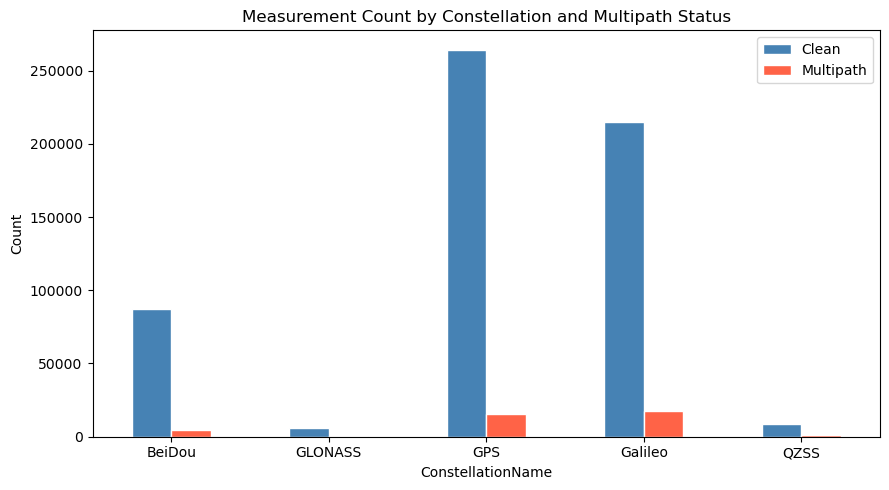

In [6]:
CONST_NAMES = {1: 'GPS', 2: 'SBAS', 3: 'GLONASS', 4: 'QZSS', 5: 'BeiDou', 6: 'Galileo'}
df['ConstellationName'] = df['ConstellationType'].map(CONST_NAMES).fillna('Unknown')

const_mp = (df.groupby(['ConstellationName', 'MultipathIndicator']).size()
            .unstack(fill_value=0).rename(columns={0: 'Clean', 1: 'Multipath'}))
if 'Multipath' in const_mp.columns and 'Clean' in const_mp.columns:
    const_mp['Multipath_%'] = (100 * const_mp['Multipath'] / const_mp.sum(axis=1)).round(1)
print(const_mp.sort_values('Multipath_%', ascending=False))

const_mp[['Clean', 'Multipath']].plot(kind='bar', figsize=(9, 5),
        color=['steelblue', 'tomato'], edgecolor='white')
plt.title('Measurement Count by Constellation and Multipath Status')
plt.ylabel('Count'); plt.xticks(rotation=0)
plt.legend(['Clean', 'Multipath'])
plt.tight_layout()
plt.show()

## 7. Correlation Analysis

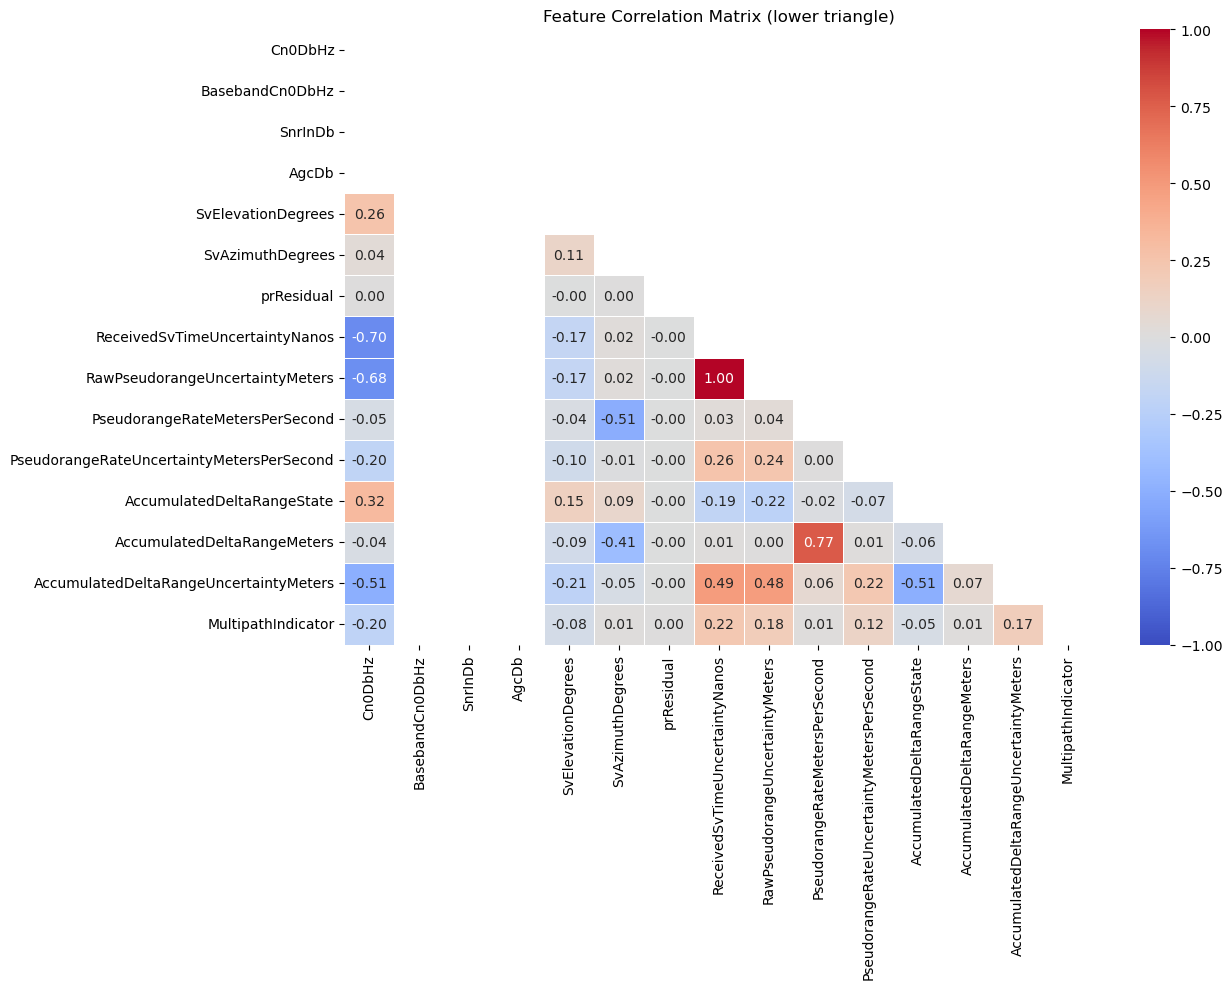


Correlation with MultipathIndicator (sorted):
ReceivedSvTimeUncertaintyNanos               0.222120
Cn0DbHz                                     -0.204214
RawPseudorangeUncertaintyMeters              0.180809
AccumulatedDeltaRangeUncertaintyMeters       0.174296
PseudorangeRateUncertaintyMetersPerSecond    0.119714
SvElevationDegrees                          -0.077901
AccumulatedDeltaRangeState                  -0.050793
PseudorangeRateMetersPerSecond               0.012664
AccumulatedDeltaRangeMeters                  0.010043
SvAzimuthDegrees                             0.008290
prResidual                                   0.000566
BasebandCn0DbHz                                   NaN
SnrInDb                                           NaN
AgcDb                                             NaN
Name: MultipathIndicator, dtype: float64


In [7]:
NUMERIC_FEATS = [
    'Cn0DbHz', 'BasebandCn0DbHz', 'SnrInDb', 'AgcDb',
    'SvElevationDegrees', 'SvAzimuthDegrees', 'prResidual',
    'ReceivedSvTimeUncertaintyNanos', 'RawPseudorangeUncertaintyMeters',
    'PseudorangeRateMetersPerSecond', 'PseudorangeRateUncertaintyMetersPerSecond',
    'AccumulatedDeltaRangeState', 'AccumulatedDeltaRangeMeters',
    'AccumulatedDeltaRangeUncertaintyMeters', 'MultipathIndicator',
]
available_num = [f for f in NUMERIC_FEATS if f in df.columns]
corr = df[available_num].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix (lower triangle)')
plt.tight_layout()
plt.show()

print('\nCorrelation with MultipathIndicator (sorted):')
print(corr['MultipathIndicator'].drop('MultipathIndicator').sort_values(key=abs, ascending=False))

## 8. Feature Engineering

Adds a C/N0 signal-strength bucket, an elevation bucket, a `|prResidual|` magnitude feature, one-hot constellation encoding, and drops identifier / non-predictive columns.

In [8]:
df_ml = df.copy()

df_ml['Cn0_Category'] = pd.cut(df_ml['Cn0DbHz'], bins=[0, 20, 30, 40, np.inf],
                               labels=['VeryWeak', 'Weak', 'Medium', 'Strong'], right=False)

if 'SvElevationDegrees' in df_ml.columns:
    df_ml['Elev_Category'] = pd.cut(df_ml['SvElevationDegrees'], bins=[-1, 15, 30, 60, 91],
                                    labels=['VeryLow', 'Low', 'Mid', 'High'])

if 'prResidual' in df_ml.columns:
    df_ml['AbsPrResidual'] = df_ml['prResidual'].abs()

df_ml = pd.get_dummies(df_ml, columns=['ConstellationName'], prefix='Const')

DROP_COLS = ['session', 'device', 'GpsTimeNanos', 'State', 'Svid',
             'ConstellationType', 'CarrierFrequencyHz']
df_ml.drop(columns=[c for c in DROP_COLS if c in df_ml.columns], inplace=True)

print('Features after engineering:')
print(list(df_ml.columns))
df_ml.head()

Features after engineering:
['ReceivedSvTimeUncertaintyNanos', 'Cn0DbHz', 'BasebandCn0DbHz', 'SnrInDb', 'AgcDb', 'PseudorangeRateMetersPerSecond', 'PseudorangeRateUncertaintyMetersPerSecond', 'AccumulatedDeltaRangeState', 'AccumulatedDeltaRangeMeters', 'AccumulatedDeltaRangeUncertaintyMeters', 'MultipathIndicator', 'SvElevationDegrees', 'SvAzimuthDegrees', 'RawPseudorangeMeters', 'RawPseudorangeUncertaintyMeters', 'prResidual', 'Cn0_Category', 'Elev_Category', 'AbsPrResidual', 'Const_BeiDou', 'Const_GLONASS', 'Const_GPS', 'Const_Galileo', 'Const_QZSS']


,ReceivedSvTimeUncertaintyNanos,Cn0DbHz,BasebandCn0DbHz,SnrInDb,AgcDb,PseudorangeRateMetersPerSecond,PseudorangeRateUncertaintyMetersPerSecond,AccumulatedDeltaRangeState,AccumulatedDeltaRangeMeters,AccumulatedDeltaRangeUncertaintyMeters,MultipathIndicator,SvElevationDegrees,SvAzimuthDegrees,RawPseudorangeMeters,RawPseudorangeUncertaintyMeters,prResidual,Cn0_Category,Elev_Category,AbsPrResidual,Const_BeiDou,Const_GLONASS,Const_GPS,Const_Galileo,Const_QZSS
0,17,35.867416,NaN,NaN,NaN,594.420187,0.002924,17,101863.658418,0.001462,0,42.065444,175.396281,2.193652e+07,5.096472,-31.072611,Medium,Mid,31.072611,False,False,True,False,False
1,12,42.319908,NaN,NaN,NaN,48.766446,0.001466,17,7419.984661,0.000733,0,69.824656,46.728665,2.053317e+07,3.597509,-20.017892,Strong,High,20.017892,False,False,True,False,False
2,21,33.128010,NaN,NaN,NaN,302.023892,0.004009,17,51046.019632,0.002004,0,13.110256,277.077207,2.439315e+07,6.295642,161.380937,Medium,VeryLow,161.380937,False,False,True,False,False
3,15,37.043587,NaN,NaN,NaN,-368.476984,0.002554,17,-64584.061018,0.001277,0,36.256790,255.396843,2.257167e+07,4.496887,2.367246,Medium,Mid,2.367246,False,False,True,False,False
4,14,37.668007,NaN,NaN,NaN,-328.389457,0.002377,17,-57639.261147,0.001188,0,54.089851,318.827182,2.119126e+07,4.197094,-2.308638,Medium,Mid,2.308638,False,False,True,False,False


## 9. Data Quality Check

In [9]:
df_ml.replace([np.inf, -np.inf], np.nan, inplace=True)

nan_counts = df_ml.isnull().sum()
print('NaN counts per column:')
print(nan_counts[nan_counts > 0] if (nan_counts > 0).any() else '  None')

all_nan_cols = nan_counts[nan_counts == len(df_ml)].index.tolist()
if all_nan_cols:
    df_ml.drop(columns=all_nan_cols, inplace=True)
    print(f'\nDropped all-NaN columns: {all_nan_cols}')

# AgcDb is only partially populated on some devices -> median fill (guarded)
if 'AgcDb' in df_ml.columns and df_ml['AgcDb'].isna().any():
    df_ml['AgcDb'] = df_ml['AgcDb'].fillna(df_ml['AgcDb'].median())
    print('Filled AgcDb NaN with median')

CORE_COLS = ['Cn0DbHz', 'SvElevationDegrees', 'ReceivedSvTimeUncertaintyNanos',
             'PseudorangeRateMetersPerSecond', 'MultipathIndicator']
core_present = [c for c in CORE_COLS if c in df_ml.columns]
before = len(df_ml)
df_ml.dropna(subset=core_present, inplace=True)
print(f'\nRows dropped (missing core): {before - len(df_ml):,}  |  Remaining: {len(df_ml):,}')

NaN counts per column:
BasebandCn0DbHz                    620636
SnrInDb                            620636
AgcDb                              620636
SvElevationDegrees                  28632
SvAzimuthDegrees                    28632
RawPseudorangeMeters                28632
RawPseudorangeUncertaintyMeters     28632
prResidual                          28632
Elev_Category                       28632
AbsPrResidual                       28632
dtype: int64

Dropped all-NaN columns: ['BasebandCn0DbHz', 'SnrInDb', 'AgcDb']

Rows dropped (missing core): 28,632  |  Remaining: 592,004


## 10. Encode Category Features

⚠️ **No scaling here.** `StandardScaler` and SMOTE are fitted on **training data only** inside the classifier notebook (after the split) to avoid leaking test-set statistics.

In [10]:
cat_cols = [c for c in ['Cn0_Category', 'Elev_Category'] if c in df_ml.columns]
if cat_cols:
    df_ml = pd.get_dummies(df_ml, columns=cat_cols, prefix=cat_cols)
    print(f'One-hot encoded: {cat_cols}')
else:
    print('Category columns already encoded — skipping')

print(f'Shape: {df_ml.shape}')
print(f'Columns: {list(df_ml.columns)}')

One-hot encoded: ['Cn0_Category', 'Elev_Category']
Shape: (592004, 27)
Columns: ['ReceivedSvTimeUncertaintyNanos', 'Cn0DbHz', 'PseudorangeRateMetersPerSecond', 'PseudorangeRateUncertaintyMetersPerSecond', 'AccumulatedDeltaRangeState', 'AccumulatedDeltaRangeMeters', 'AccumulatedDeltaRangeUncertaintyMeters', 'MultipathIndicator', 'SvElevationDegrees', 'SvAzimuthDegrees', 'RawPseudorangeMeters', 'RawPseudorangeUncertaintyMeters', 'prResidual', 'AbsPrResidual', 'Const_BeiDou', 'Const_GLONASS', 'Const_GPS', 'Const_Galileo', 'Const_QZSS', 'Cn0_Category_VeryWeak', 'Cn0_Category_Weak', 'Cn0_Category_Medium', 'Cn0_Category_Strong', 'Elev_Category_VeryLow', 'Elev_Category_Low', 'Elev_Category_Mid', 'Elev_Category_High']


## 11. Class Imbalance — Overview

Raw imbalance before any resampling. SMOTE is applied inside the classifier notebook on training data only.

In [11]:
X = df_ml.drop(columns=['MultipathIndicator'])
y = df_ml['MultipathIndicator'].astype(int)
counts = y.value_counts()
total = len(y)
print('Class distribution (raw, pre-split):')
for cls, cnt in counts.items():
    print(f'  {cls}: {cnt:,}  ({100*cnt/total:.1f}%)')
print(f'\nImbalance ratio: {counts[0]/counts[1]:.1f}:1  ->  SMOTE will balance this in the classifier.')

Class distribution (raw, pre-split):
  0: 558,573  (94.4%)
  1: 33,431  (5.6%)

Imbalance ratio: 16.7:1  ->  SMOTE will balance this in the classifier.


## 12. PCA — Variance Explained (raw, unscaled)

Orientation only — uses the unscaled numeric matrix so PCA reflects true variance magnitudes.

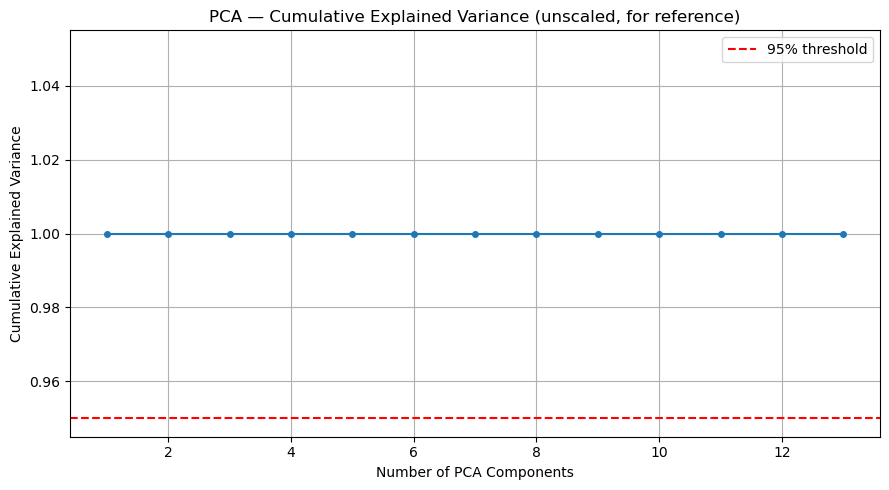

Components needed to explain 95% of variance: 1


In [12]:
bool_cols = X.select_dtypes(include='bool').columns.tolist()
num_cols  = [c for c in X.select_dtypes(include=np.number).columns if c not in bool_cols]

pca = PCA()
pca.fit(X[num_cols].fillna(0))
cumvar = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cumvar) + 1), cumvar, marker='o', markersize=4)
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance (unscaled, for reference)')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

n95 = int(np.where(cumvar >= 0.95)[0][0]) + 1
print(f'Components needed to explain 95% of variance: {n95}')

## 13. Export Training Features

In [13]:
# Raw (unscaled, pre-SMOTE) features. Scaling + SMOTE happen in
# 03_2022_classification.ipynb AFTER the train/test split to prevent leakage.
df_ml.to_csv(OUTPUT_CSV, index=False)
print(f'Saved {len(df_ml):,} rows  ->  {OUTPUT_CSV}')
print(f'Shape: {df_ml.shape}')
df_ml.head()

Saved 592,004 rows  ->  C:\Users\Dell\Documents\Warwick\Diss\Code\Dissertation_Trial\GNSS_Multipath_Project\data/03_processed\sdc2022_training_features.csv
Shape: (592004, 27)


,ReceivedSvTimeUncertaintyNanos,Cn0DbHz,PseudorangeRateMetersPerSecond,PseudorangeRateUncertaintyMetersPerSecond,AccumulatedDeltaRangeState,AccumulatedDeltaRangeMeters,AccumulatedDeltaRangeUncertaintyMeters,MultipathIndicator,SvElevationDegrees,SvAzimuthDegrees,RawPseudorangeMeters,RawPseudorangeUncertaintyMeters,prResidual,AbsPrResidual,Const_BeiDou,Const_GLONASS,Const_GPS,Const_Galileo,Const_QZSS,Cn0_Category_VeryWeak,Cn0_Category_Weak,Cn0_Category_Medium,Cn0_Category_Strong,Elev_Category_VeryLow,Elev_Category_Low,Elev_Category_Mid,Elev_Category_High
0,17,35.867416,594.420187,0.002924,17,101863.658418,0.001462,0,42.065444,175.396281,2.193652e+07,5.096472,-31.072611,31.072611,False,False,True,False,False,False,False,True,False,False,False,True,False
1,12,42.319908,48.766446,0.001466,17,7419.984661,0.000733,0,69.824656,46.728665,2.053317e+07,3.597509,-20.017892,20.017892,False,False,True,False,False,False,False,False,True,False,False,False,True
2,21,33.128010,302.023892,0.004009,17,51046.019632,0.002004,0,13.110256,277.077207,2.439315e+07,6.295642,161.380937,161.380937,False,False,True,False,False,False,False,True,False,True,False,False,False
3,15,37.043587,-368.476984,0.002554,17,-64584.061018,0.001277,0,36.256790,255.396843,2.257167e+07,4.496887,2.367246,2.367246,False,False,True,False,False,False,False,True,False,False,False,True,False
4,14,37.668007,-328.389457,0.002377,17,-57639.261147,0.001188,0,54.089851,318.827182,2.119126e+07,4.197094,-2.308638,2.308638,False,False,True,False,False,False,False,True,False,False,False,True,False
